In [2]:
import cv2

print(cv2.__version__)

4.11.0


In [3]:
cap = cv2.VideoCapture(0)

print(cap.isOpened())

True


In [4]:
ret, frame = cap.read()

print("Success:", ret)
print("Shape:", frame.shape)

Success: True
Shape: (480, 640, 3)


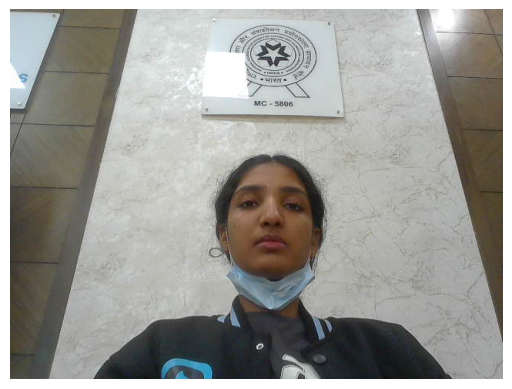

In [5]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [6]:
pixel = frame[100, 200]

print(pixel)

[219 222 220]


In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print(face_cascade.empty())

False


In [8]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5
)

print(faces)

[[264 190 149 149]]


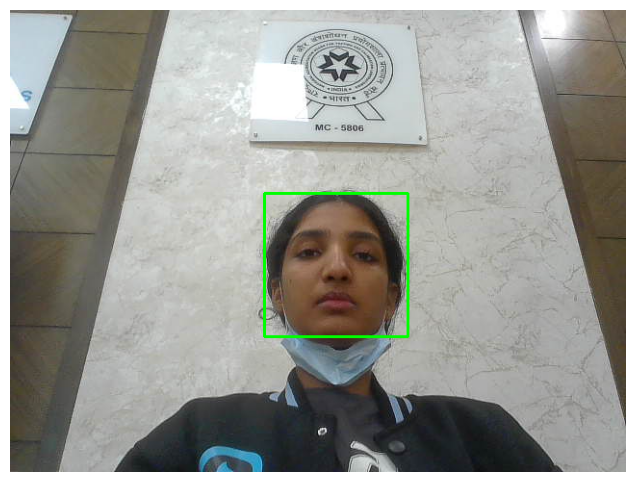

In [9]:
display_frame = frame.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(
        display_frame,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
plt.axis("off");

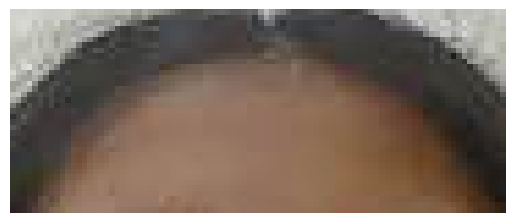

In [10]:
x, y, w, h = faces[0]

forehead = frame[
    y : y + int(0.25 * h),
    x + int(0.2 * w) : x + int(0.8 * w)
]

plt.imshow(cv2.cvtColor(forehead, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [11]:
avg_bgr = forehead.mean(axis=(0, 1))

print("Average BGR:", avg_bgr)

Average BGR: [ 83.03033033  95.49309309 112.79489489]


In [12]:
fps = cap.get(cv2.CAP_PROP_FPS)

print("FPS:", fps)

FPS: 30.0


In [13]:
import numpy as np

blue_signal = []
green_signal = []
red_signal = []

print("Storage ready")

Storage ready


In [14]:
import time

duration = 10
start_time = time.time()

while time.time() - start_time < duration:

    ret, frame = cap.read()

    if not ret:
        continue

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(faces) == 0:
        continue

    x, y, w, h = faces[0]

    forehead = frame[
        y:y + int(0.25 * h),
        x + int(0.2 * w):x + int(0.8 * w)
    ]

    avg_bgr = forehead.mean(axis=(0, 1))

    blue_signal.append(avg_bgr[0])
    green_signal.append(avg_bgr[1])
    red_signal.append(avg_bgr[2])

print("Frames collected:", len(green_signal))

Frames collected: 301


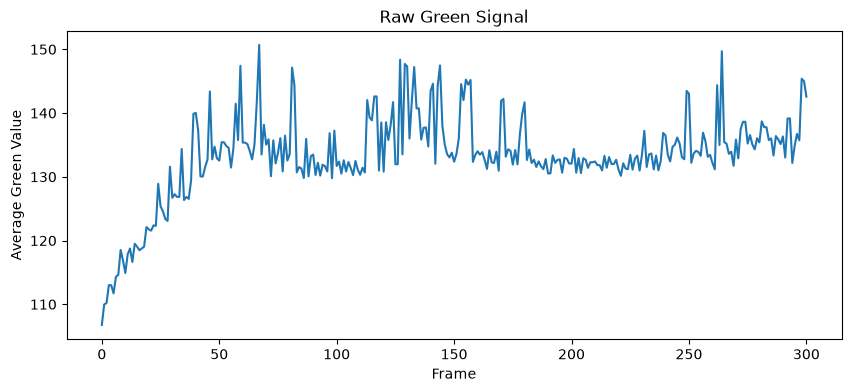

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(green_signal)

plt.xlabel("Frame")
plt.ylabel("Average Green Value")
plt.title("Raw Green Signal")
plt.show()

In [16]:
from scipy import signal

In [17]:
print("SciPy loaded")

SciPy loaded


In [18]:
green_detrended = signal.detrend(green_signal)

print("Original first 5:", green_signal[:5])
print("Detrended first 5:", green_detrended[:5])

Original first 5: [np.float64(106.75630252100841), np.float64(109.96953781512605), np.float64(110.19795657726692), np.float64(113.01020408163265), np.float64(112.98405315614617)]
Detrended first 5: [-21.62040791 -18.43998372 -18.24437607 -15.46493967 -15.52390171]


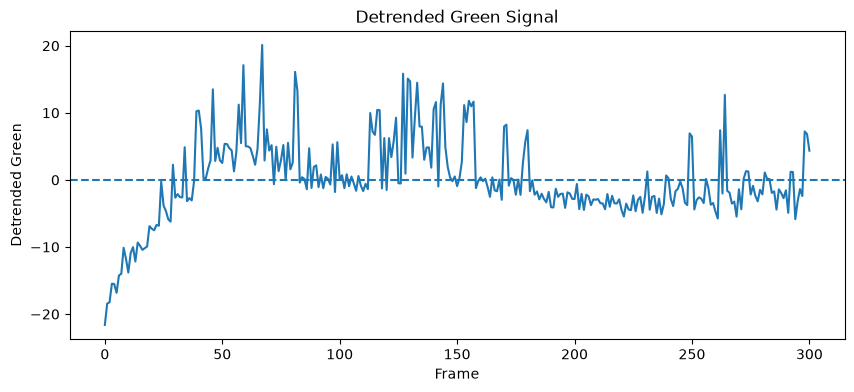

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(green_detrended)

plt.xlabel("Frame")
plt.ylabel("Detrended Green")
plt.title("Detrended Green Signal")

plt.axhline(0, linestyle="--")
plt.show()

In [20]:
lowcut = 0.7
highcut = 4.0
order = 3

b, a = signal.butter(
    order,
    [lowcut, highcut],
    btype="bandpass",
    fs=fps
)

print("Filter created")

Filter created


In [21]:
green_filtered = signal.filtfilt(
    b,
    a,
    green_detrended
)

print("Filtered signal created")

Filtered signal created


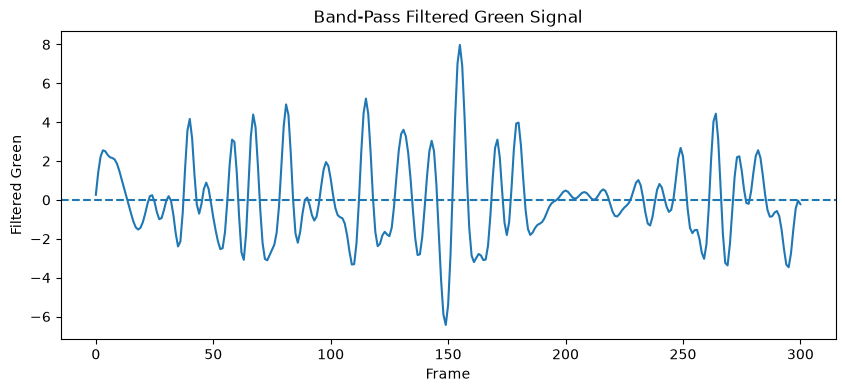

In [22]:
plt.figure(figsize=(10, 4))

plt.plot(green_filtered)

plt.xlabel("Frame")
plt.ylabel("Filtered Green")
plt.title("Band-Pass Filtered Green Signal")
plt.axhline(0, linestyle="--")

plt.show()

In [23]:
n = len(green_filtered)

fft_values = np.fft.rfft(green_filtered)
frequencies = np.fft.rfftfreq(n, d=1/fps)

magnitude = np.abs(fft_values)

print("Samples:", n)
print("Frequency bins:", len(frequencies))

Samples: 301
Frequency bins: 151


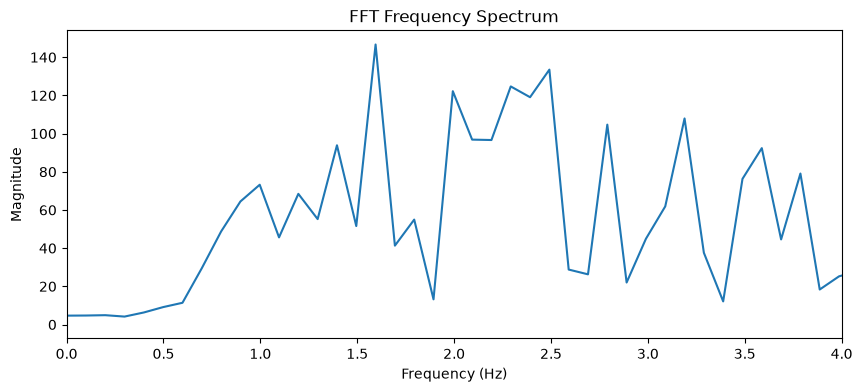

In [24]:
plt.figure(figsize=(10, 4))

plt.plot(frequencies, magnitude)

plt.xlim(0, 4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Frequency Spectrum")

plt.show()

In [25]:
valid = (frequencies >= 0.7) & (frequencies <= 4.0)

peak_index = np.argmax(magnitude[valid])

valid_frequencies = frequencies[valid]

dominant_frequency = valid_frequencies[peak_index]

heart_rate = dominant_frequency * 60

print(f"Dominant Frequency: {dominant_frequency:.2f} Hz")
print(f"Estimated Heart Rate: {heart_rate:.0f} BPM")

Dominant Frequency: 1.59 Hz
Estimated Heart Rate: 96 BPM


In [26]:
timestamps = []
green_signal = []
red_signal = []
blue_signal = []

print("Timestamped storage ready")

Timestamped storage ready


In [27]:
import time

duration = 10
start_time = time.perf_counter()

while time.perf_counter() - start_time < duration:

    ret, frame = cap.read()

    if not ret:
        continue

    current_time = time.perf_counter() - start_time

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(faces) == 0:
        continue

    x, y, w, h = faces[0]

    forehead = frame[
        y:y + int(0.25 * h),
        x + int(0.2 * w):x + int(0.8 * w)
    ]

    avg_bgr = forehead.mean(axis=(0, 1))

    timestamps.append(current_time)
    blue_signal.append(avg_bgr[0])
    green_signal.append(avg_bgr[1])
    red_signal.append(avg_bgr[2])

print("Samples collected:", len(green_signal))
print("Elapsed time:", timestamps[-1], "seconds")

Samples collected: 301
Elapsed time: 9.983324200031348 seconds


In [28]:
actual_duration = timestamps[-1] - timestamps[0]

actual_fps = (len(timestamps) - 1) / actual_duration

print(f"Actual sampling rate: {actual_fps:.2f} Hz")

Actual sampling rate: 30.06 Hz


In [29]:
intervals = np.diff(timestamps)

print("Average interval:", np.mean(intervals))
print("Minimum interval:", np.min(intervals))
print("Maximum interval:", np.max(intervals))

Average interval: 0.03326503699994646
Minimum interval: 0.021297800005413592
Maximum interval: 0.053215299965813756


In [30]:
print("First 5 timestamps:")
print(timestamps[:5])

print("\nLast 5 timestamps:")
print(timestamps[-5:])

First 5 timestamps:
[0.0038131000474095345, 0.05208180006593466, 0.09082680009305477, 0.12544319999869913, 0.15037769998889416]

Last 5 timestamps:
[9.839837100007571, 9.876066700089723, 9.91568970005028, 9.944785100058652, 9.983324200031348]


In [31]:
intervals = np.diff(timestamps)

negative_indices = np.where(intervals < 0)[0]

print("Negative intervals:", len(negative_indices))
print("Indices:", negative_indices[:10])

for i in negative_indices[:5]:
    print(
        f"Before: {timestamps[i]:.6f}, "
        f"After: {timestamps[i+1]:.6f}, "
        f"Difference: {intervals[i]:.6f}"
    )

Negative intervals: 0
Indices: []


In [32]:
actual_fps = (len(timestamps) - 1) / (timestamps[-1] - timestamps[0])

uniform_time = np.arange(
    timestamps[0],
    timestamps[-1],
    1 / actual_fps
)

green_uniform = np.interp(
    uniform_time,
    timestamps,
    green_signal
)

print("Actual FPS:", actual_fps)
print("Original samples:", len(green_signal))
print("Uniform samples:", len(green_uniform))

Actual FPS: 30.061592897119265
Original samples: 301
Uniform samples: 301


In [33]:
green_uniform_detrended = signal.detrend(green_uniform)

print("Detrended signal length:", len(green_uniform_detrended))

Detrended signal length: 301


In [34]:
fs_actual = actual_fps

lowcut = 0.7
highcut = 4.0
order = 3

b, a = signal.butter(
    order,
    [lowcut, highcut],
    btype="bandpass",
    fs=fs_actual
)

print(f"Filter sampling rate: {fs_actual:.2f} Hz")
print("Filter created")

Filter sampling rate: 30.06 Hz
Filter created


In [35]:
green_uniform_filtered = signal.filtfilt(
    b,
    a,
    green_uniform_detrended
)

print("Filtered signal length:", len(green_uniform_filtered))

Filtered signal length: 301


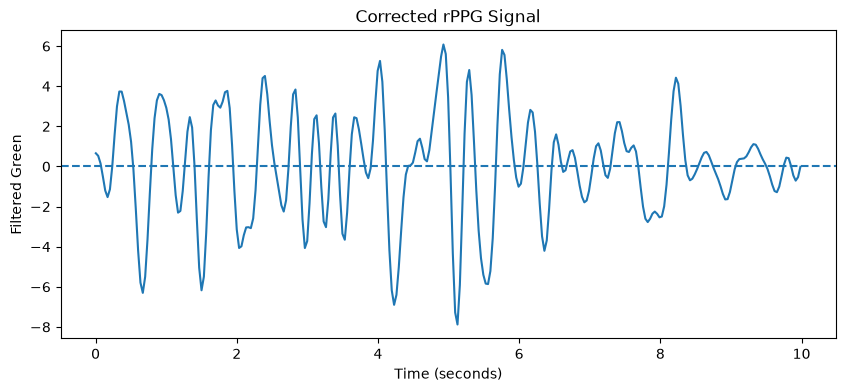

In [36]:
plt.figure(figsize=(10, 4))

plt.plot(uniform_time, green_uniform_filtered)

plt.xlabel("Time (seconds)")
plt.ylabel("Filtered Green")
plt.title("Corrected rPPG Signal")

plt.axhline(0, linestyle="--")
plt.show()

In [37]:
n = len(green_uniform_filtered)

fft_values = np.fft.rfft(green_uniform_filtered)
frequencies = np.fft.rfftfreq(n, d=1/fs_actual)

magnitude = np.abs(fft_values)

print("Samples:", n)
print(f"Frequency resolution: {fs_actual/n:.3f} Hz")

Samples: 301
Frequency resolution: 0.100 Hz


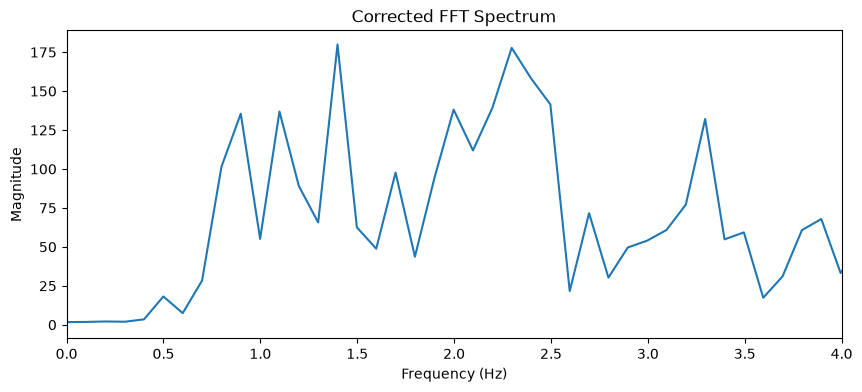

In [38]:
plt.figure(figsize=(10, 4))

plt.plot(frequencies, magnitude)

plt.xlim(0, 4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Corrected FFT Spectrum")

plt.show()

In [39]:
R = np.array(red_signal)
G = np.array(green_signal)
B = np.array(blue_signal)

R_norm = R / np.mean(R)
G_norm = G / np.mean(G)
B_norm = B / np.mean(B)

print("Mean normalized R:", np.mean(R_norm))
print("Mean normalized G:", np.mean(G_norm))
print("Mean normalized B:", np.mean(B_norm))

Mean normalized R: 1.0
Mean normalized G: 0.9999999999999998
Mean normalized B: 0.9999999999999998


In [40]:
X = 3 * R_norm - 2 * G_norm
Y = 1.5 * R_norm + G_norm - 1.5 * B_norm

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (301,)
Y shape: (301,)


In [41]:
std_X = np.std(X)
std_Y = np.std(Y)

print("Std X:", std_X)
print("Std Y:", std_Y)

Std X: 0.026425628387243185
Std Y: 0.013583061913611109


In [42]:
alpha = std_X / std_Y

print("Alpha:", alpha)

Alpha: 1.9454839089530316


In [44]:
chrom_signal = X - alpha * Y

print("CHROM signal shape:", chrom_signal.shape)
print("First 5 values:", chrom_signal[:5])

CHROM signal shape: (301,)
First 5 values: [-0.93288677 -0.93476502 -0.92747938 -0.93944289 -0.93299529]


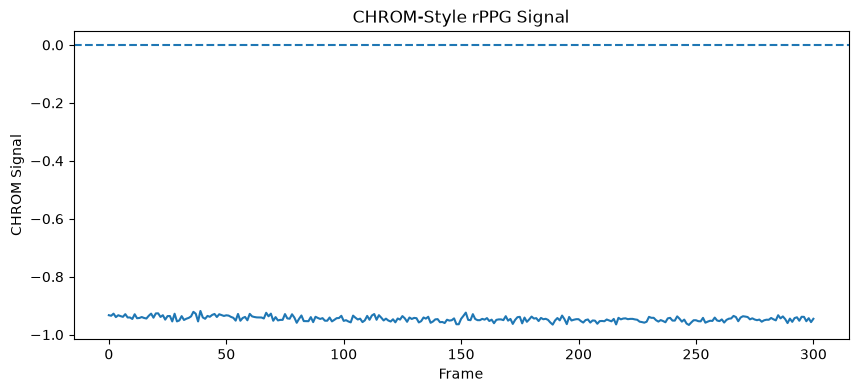

In [45]:
plt.figure(figsize=(10, 4))

plt.plot(chrom_signal)

plt.xlabel("Frame")
plt.ylabel("CHROM Signal")
plt.title("CHROM-Style rPPG Signal")

plt.axhline(0, linestyle="--")

plt.show()

In [46]:
print("Mean:", np.mean(chrom_signal))
print("Std:", np.std(chrom_signal))
print("Min:", np.min(chrom_signal))
print("Max:", np.max(chrom_signal))

Mean: -0.945483908953032
Std: 0.008837963432972237
Min: -0.9664825389685932
Max: -0.9182403494872868


In [47]:
chrom_centered = chrom_signal - np.mean(chrom_signal)

print("Mean:", np.mean(chrom_centered))
print("Std:", np.std(chrom_centered))

Mean: -5.975286710607154e-17
Std: 0.008837963432972237


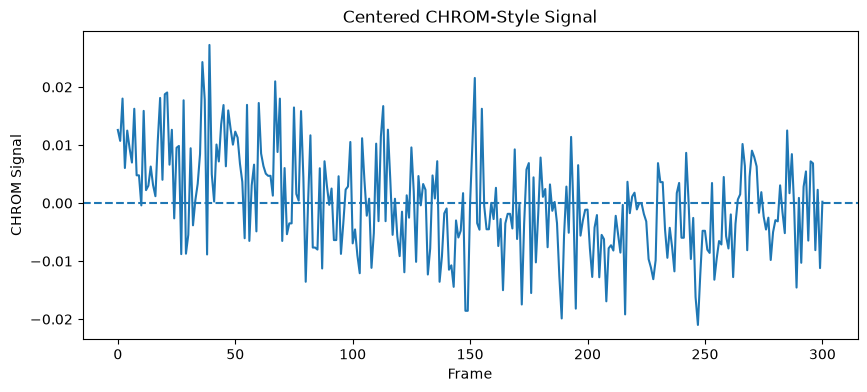

In [48]:
plt.figure(figsize=(10, 4))

plt.plot(chrom_centered)

plt.xlabel("Frame")
plt.ylabel("CHROM Signal")
plt.title("Centered CHROM-Style Signal")

plt.axhline(0, linestyle="--")

plt.show()

In [49]:
window_size = int(5 * actual_fps)

R_window = R[:window_size]
G_window = G[:window_size]
B_window = B[:window_size]

print("Window samples:", len(R_window))

Window samples: 150


In [50]:
R_norm_window = R_window / np.mean(R_window)
G_norm_window = G_window / np.mean(G_window)
B_norm_window = B_window / np.mean(B_window)

print("R mean:", np.mean(R_norm_window))
print("G mean:", np.mean(G_norm_window))
print("B mean:", np.mean(B_norm_window))

R mean: 1.0
G mean: 1.0
B mean: 1.0


In [51]:
X_window = 3 * R_norm_window - 2 * G_norm_window

Y_window = 1.5 * R_norm_window + G_norm_window - 1.5 * B_norm_window

print("X shape:", X_window.shape)
print("Y shape:", Y_window.shape)

X shape: (150,)
Y shape: (150,)


In [52]:
std_X_window = np.std(X_window)
std_Y_window = np.std(Y_window)

alpha_window = std_X_window / std_Y_window

print("Std X:", std_X_window)
print("Std Y:", std_Y_window)
print("Alpha:", alpha_window)

Std X: 0.02421267605079253
Std Y: 0.01041934378532812
Alpha: 2.3238196713393156


In [53]:
chrom_window = X_window - alpha_window * Y_window

print("CHROM window shape:", chrom_window.shape)
print("First 5 values:", chrom_window[:5])

CHROM window shape: (150,)
First 5 values: [-1.31765604 -1.31746078 -1.30937992 -1.32453115 -1.31613551]


In [54]:
chrom_window_centered = chrom_window - np.mean(chrom_window)

print("Mean:", np.mean(chrom_window_centered))
print("Std:", np.std(chrom_window_centered))

Mean: -1.554312234475219e-16
Std: 0.009647933174019076


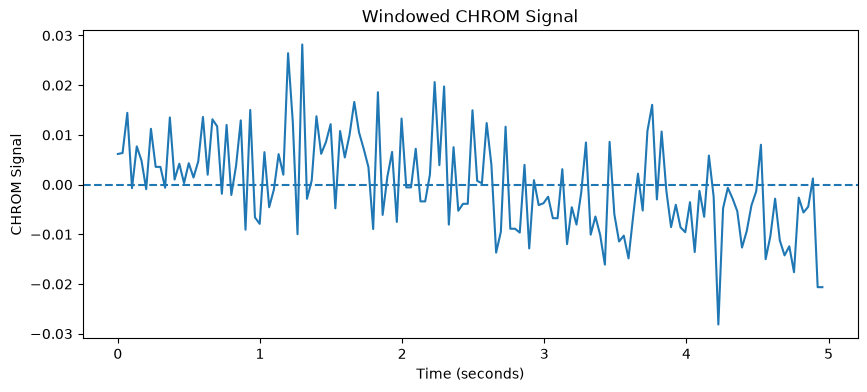

In [55]:
window_time = np.arange(len(chrom_window_centered)) / actual_fps

plt.figure(figsize=(10, 4))

plt.plot(window_time, chrom_window_centered)

plt.xlabel("Time (seconds)")
plt.ylabel("CHROM Signal")
plt.title("Windowed CHROM Signal")

plt.axhline(0, linestyle="--")

plt.show()

In [56]:
b_chrom, a_chrom = signal.butter(
    3,
    [0.7, 4.0],
    btype="bandpass",
    fs=actual_fps
)

chrom_filtered = signal.filtfilt(
    b_chrom,
    a_chrom,
    chrom_window_centered
)

print("Filtered CHROM length:", len(chrom_filtered))

Filtered CHROM length: 150


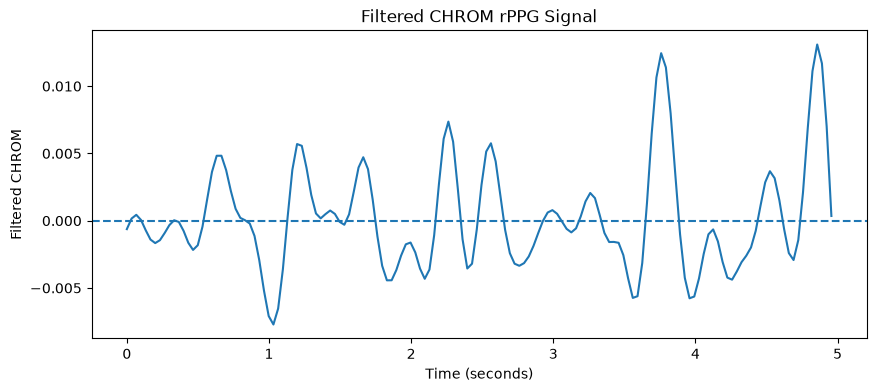

In [57]:
plt.figure(figsize=(10, 4))

plt.plot(window_time, chrom_filtered)

plt.xlabel("Time (seconds)")
plt.ylabel("Filtered CHROM")
plt.title("Filtered CHROM rPPG Signal")

plt.axhline(0, linestyle="--")

plt.show()

In [58]:
n_chrom = len(chrom_filtered)

fft_chrom = np.fft.rfft(chrom_filtered)

freq_chrom = np.fft.rfftfreq(
    n_chrom,
    d=1 / actual_fps
)

mag_chrom = np.abs(fft_chrom)

print("Samples:", n_chrom)
print(f"Frequency resolution: {actual_fps / n_chrom:.3f} Hz")

Samples: 150
Frequency resolution: 0.200 Hz


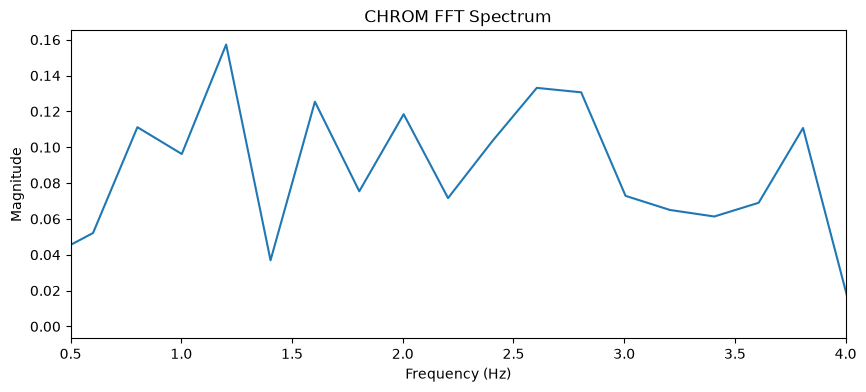

In [59]:
plt.figure(figsize=(10, 4))

plt.plot(freq_chrom, mag_chrom)

plt.xlim(0.5, 4.0)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("CHROM FFT Spectrum")

plt.show()

In [60]:
cap = cv2.VideoCapture(0)

print("Camera opened:", cap.isOpened())

Camera opened: True


In [61]:
timestamps = []
red_signal = []
green_signal = []
blue_signal = []

print("Respiration recording storage ready")

Respiration recording storage ready


In [62]:
import time

duration = 30
start_time = time.perf_counter()

while time.perf_counter() - start_time < duration:

    ret, frame = cap.read()

    if not ret:
        continue

    current_time = time.perf_counter() - start_time

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(faces) == 0:
        continue

    x, y, w, h = faces[0]

    forehead = frame[
        y:y + int(0.25 * h),
        x + int(0.2 * w):x + int(0.8 * w)
    ]

    avg_bgr = forehead.mean(axis=(0, 1))

    timestamps.append(current_time)
    blue_signal.append(avg_bgr[0])
    green_signal.append(avg_bgr[1])
    red_signal.append(avg_bgr[2])

print("Samples collected:", len(green_signal))
print("Elapsed time:", timestamps[-1], "seconds")

Samples collected: 879
Elapsed time: 29.99930449994281 seconds


In [63]:
actual_fps = (len(timestamps) - 1) / (timestamps[-1] - timestamps[0])

print(f"Actual sampling rate: {actual_fps:.2f} Hz")

Actual sampling rate: 30.03 Hz


In [64]:
intervals = np.diff(timestamps)

print("Negative intervals:", np.sum(intervals < 0))
print("Average interval:", np.mean(intervals))
print("Minimum interval:", np.min(intervals))
print("Maximum interval:", np.max(intervals))


Negative intervals: 0
Average interval: 0.033299976993105024
Minimum interval: 0.023188799968920648
Maximum interval: 0.06660409993492067


In [65]:
G_resp = np.array(green_signal)

print("Samples:", len(G_resp))
G_resp_detrended = signal.detrend(G_resp)

print("Detrended respiration signal created")

Samples: 879
Detrended respiration signal created


In [66]:
resp_low = 0.1
resp_high = 0.5
resp_order = 3

b_resp, a_resp = signal.butter(
    resp_order,
    [resp_low, resp_high],
    btype="bandpass",
    fs=actual_fps
)

print(f"Respiration filter: {resp_low}-{resp_high} Hz")
print(f"Sampling rate: {actual_fps:.2f} Hz")

Respiration filter: 0.1-0.5 Hz
Sampling rate: 30.03 Hz


In [67]:
resp_filtered = signal.filtfilt(
    b_resp,
    a_resp,
    G_resp_detrended
)

print("Filtered respiration signal length:", len(resp_filtered))

Filtered respiration signal length: 879


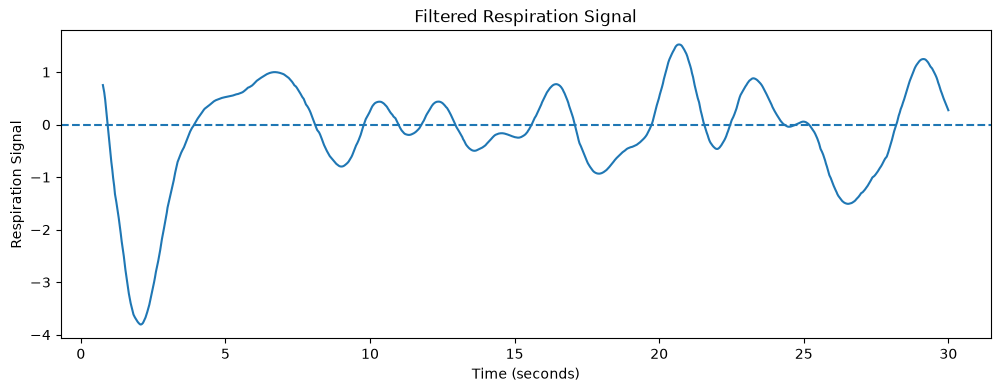

In [68]:
resp_time = np.array(timestamps)

plt.figure(figsize=(12, 4))

plt.plot(resp_time, resp_filtered)

plt.xlabel("Time (seconds)")
plt.ylabel("Respiration Signal")
plt.title("Filtered Respiration Signal")

plt.axhline(0, linestyle="--")

plt.show()

In [69]:
n_resp = len(resp_filtered)

fft_resp = np.fft.rfft(resp_filtered)

freq_resp = np.fft.rfftfreq(
    n_resp,
    d=1 / actual_fps
)

mag_resp = np.abs(fft_resp)

print("Samples:", n_resp)
print(f"Frequency resolution: {actual_fps / n_resp:.3f} Hz")

Samples: 879
Frequency resolution: 0.034 Hz


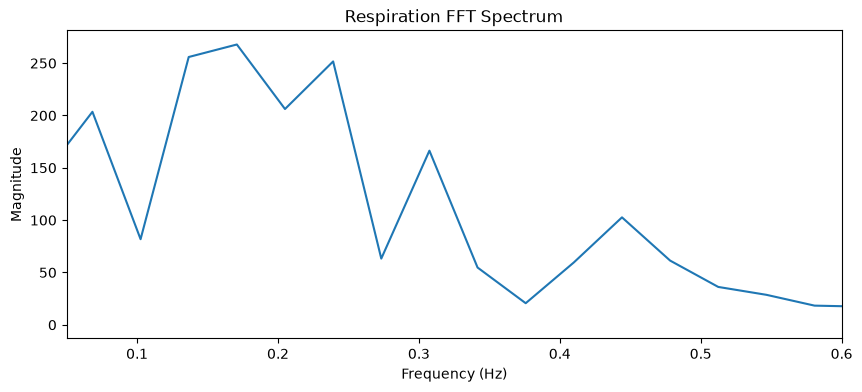

In [70]:
plt.figure(figsize=(10, 4))

plt.plot(freq_resp, mag_resp)

plt.xlim(0.05, 0.6)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Respiration FFT Spectrum")

plt.show()

In [71]:
resp_valid = (freq_resp >= 0.1) & (freq_resp <= 0.5)

peak_idx = np.argmax(mag_resp[resp_valid])

valid_freqs = freq_resp[resp_valid]

dominant_resp_freq = valid_freqs[peak_idx]

respiration_rate = dominant_resp_freq * 60

print(f"Dominant respiration frequency: {dominant_resp_freq:.3f} Hz")
print(f"Estimated respiration rate: {respiration_rate:.1f} breaths/min")

Dominant respiration frequency: 0.171 Hz
Estimated respiration rate: 10.2 breaths/min
